In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Import Dataset and Preliminary Operations

In [4]:
df = pd.read_excel("Data_w_cat_children_NEW.xlsx")
Dataset = df.copy()

print("Dataset dimensions:", Dataset.shape)    # originally 3245 x 93
                                               # now 3241 
                                               # 2 rows were deleted because they were empty on excel, the other two were eliminated because the patients were above 30 y.o.

# Print the number of missing values for each column

pd.options.display.max_rows = len(np.sum(Dataset.isna()))
print(np.sum(Dataset.isna()))

Dataset dimensions: (3241, 94)
Patient_ID                          0
Local_ID                            0
Center                            466
Sex                                 1
Ethnicity                           4
Year_of_Diagnosis                   0
Age_at_Diagnosis                    1
Age_Years                           0
Age_Months                         36
Month_Gluten_Started              697
Weight                            321
Height                            371
Growth Delay Updated               13
BMI                               371
Recent_Gastroenteritis              1
Education_Parents                2190
Num_Siblings                      953
Socioecon_Status                 2168
Exemption                        1671
Blood_Count                        51
BloodCount_NotReported              0
BloodCount_Microcytic_Anemia        0
BloodCount_Macrocytic_Anemia        0
BloodCount_Normocytic_Anemia        0
BloodCount_Piastrinopenia           0
BloodCount_Pancytop

In [ ]:
# Check if all patients' ID are unique

print("Number of unique rows in the dataset:", Dataset['Local_ID'].nunique())


Number of unique rows in the dataset: 3241


## Height, Weight and Age

The goal of this section is to idenfity eventual outliers for Height, Weight or Age.

The idea is to divide the dataset into age groups (almost homogeneous in terms of height and weight), and eventually also distinguish between males and females for age group > 13 years old.

### Boxplots without age groups

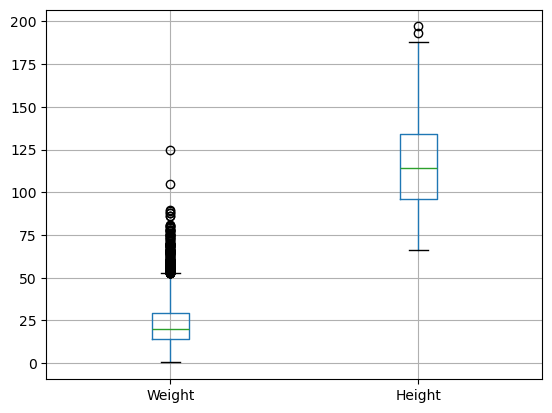

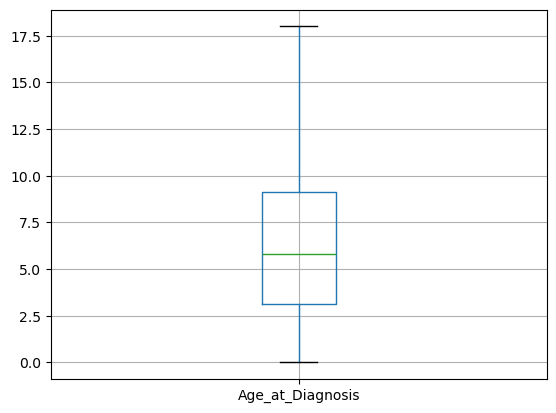

In [ ]:
plt.figure(1)
Dataset.boxplot(column = ['Weight', 'Height'])
plt.show()

plt.figure(2)
Dataset.boxplot(column = ['Age_at_Diagnosis'])
plt.show()

### Boxplots with age groups

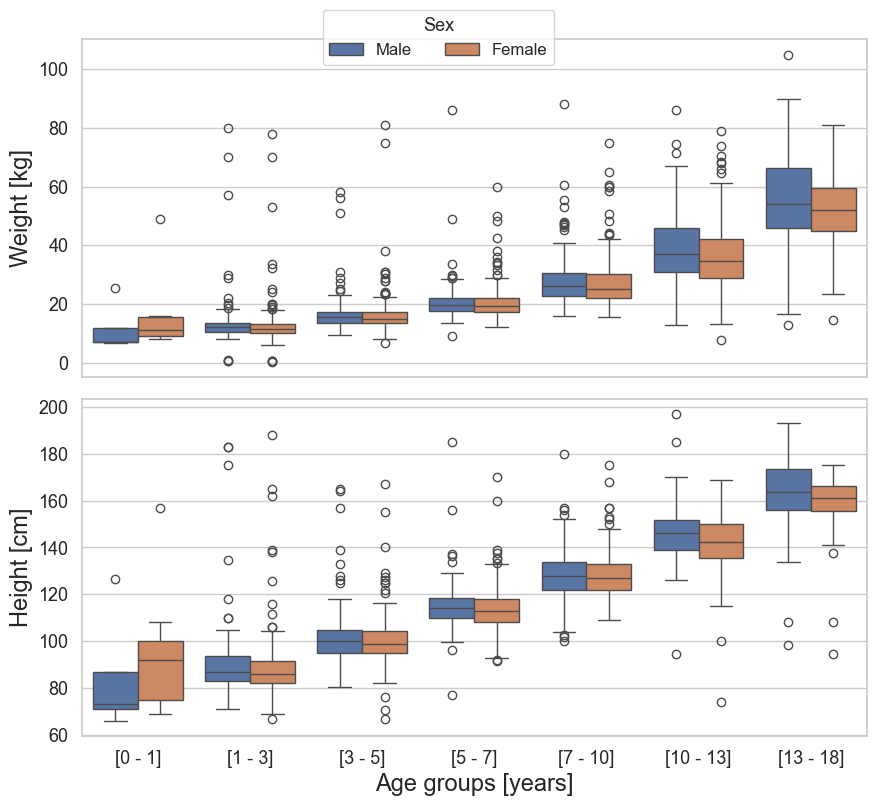

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========
# 1. Age groups
# =========

age_group_order = ["[0 - 1]", "[1 - 3]", "[3 - 5]", "[5 - 7]", "[7 - 10]", "[10 - 13]", "[13 - 18]"]

def categorize_age(age):
    if pd.isna(age):
        return "Unknown"
    elif age < 1:
        return "[0 - 1]"
    elif age < 3:
        return "[1 - 3]"
    elif age < 5:
        return "[3 - 5]"
    elif age < 7:
        return "[5 - 7]"
    elif age < 10:
        return "[7 - 10]"
    elif age < 13:
        return "[10 - 13]"
    else:
        return "[13 - 18]"

Dataset["Age_Group"] = Dataset["Age_Years"].apply(categorize_age)
Dataset["Age_Group"] = pd.Categorical(Dataset["Age_Group"],
                                      categories=age_group_order,
                                      ordered=True)

# =========
# 2. Sex label
# =========
sex_map = {0.0: "Male", 1.0: "Female", 0: "Male", 1: "Female"}
Dataset["Sex_Label"] = Dataset["Sex"].map(sex_map)

plot_data = Dataset.dropna(subset=["Age_Group", "Sex_Label", "Weight", "Height"])

# =========
# 3. Style
# =========
sns.set(style="whitegrid", font_scale=1.2)

# =========
# 4. Single figure with 2 stacked subplots
# =========
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

## Top subplot -> Weight
sns.boxplot(
    data=plot_data,
    x="Age_Group",
    y="Weight",
    hue="Sex_Label",
    order=age_group_order,
    ax=axes[0]
)
axes[0].set_xlabel("")  # no x label on top subplot
axes[0].set_ylabel("Weight [kg]", fontsize=17)
axes[0].tick_params(axis="x", labelsize=13)
axes[0].tick_params(axis="y", labelsize=13)
axes[0].legend_.set_title("Sex")

# we'll reuse the legend from the top subplot, so remove it from bottom later
legend_handles, legend_labels = axes[0].get_legend_handles_labels()

## Bottom subplot -> Height
sns.boxplot(
    data=plot_data,
    x="Age_Group",
    y="Height",
    hue="Sex_Label",
    order=age_group_order,
    ax=axes[1]
)
axes[1].set_xlabel("Age groups [years]", fontsize=17)
axes[1].set_ylabel("Height [cm]", fontsize=17)
axes[1].tick_params(axis="x", labelsize=13)
axes[1].tick_params(axis="y", labelsize=13)

# remove duplicated legend from bottom subplot
axes[0].legend_.remove()
axes[1].legend_.remove()

# optional: put a single shared legend above or below
fig.legend(
    legend_handles,
    legend_labels,
    title="Sex",
    loc="upper center",
    ncol=2,
    frameon=True,
    fontsize=12,
    title_fontsize=13,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout()
#plt.savefig("Age_Group_Boxplots.png", dpi=300, bbox_inches='tight')
plt.show()


In [7]:
Dataset["Age_Group"].value_counts()

[3 - 5]      704
[1 - 3]      661
[7 - 10]     618
[5 - 7]      542
[10 - 13]    434
[13 - 18]    270
[0 - 1]       12
Name: Age_Group, dtype: int64

## Blood Anomalies

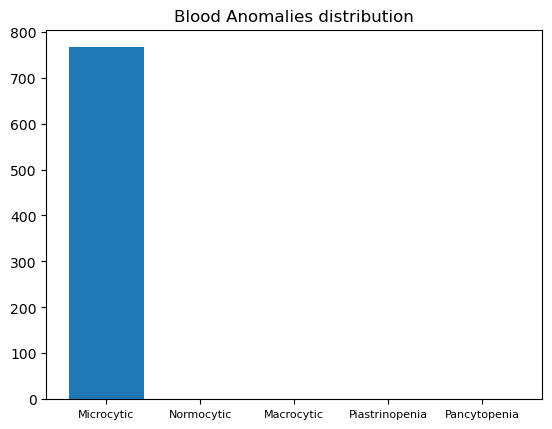

In [ ]:
# BARCHART

Total_Blood_Anomalies = Dataset['Blood_Count'].sum()                   # 766.00
Microcytic = Dataset['BloodCount_Microcytic_Anemia'].sum()             # 766.00
Normocytic = Dataset['BloodCount_Normocytic_Anemia'].sum()             # 0
Macrocytic = Dataset['BloodCount_Macrocytic_Anemia'].sum()             # 0
Piastrinopenia = Dataset['BloodCount_Piastrinopenia'].sum()            # 0
Pancytopenia = Dataset['BloodCount_Pancytopenia'].sum()                # 0

plt.figure(3)
plt.bar(['Microcytic', 'Normocytic', 'Macrocytic', 'Piastrinopenia', 'Pancytopenia'],
        [Microcytic, Normocytic, Macrocytic, Piastrinopenia, Pancytopenia], width=0.8)
plt.xticks(['Microcytic', 'Normocytic', 'Macrocytic', 'Piastrinopenia', 'Pancytopenia'], fontsize=8)
plt.title("Blood Anomalies distribution")
plt.show()

We can drop all columns for which we have no observations, since they do not provide any useful information.
Moreover, we drop the column related to the absence of Blood anomalies (which is the complementary to the previous one)

In [ ]:
# Drop columns

Dataset = Dataset.drop(columns=['BloodCount_Normocytic_Anemia', 'BloodCount_Macrocytic_Anemia', 'BloodCount_Piastrinopenia','BloodCount_Pancytopenia'])
Dataset = Dataset.drop(columns='BloodCount_NotReported')


## Gastrointestinal Symptoms

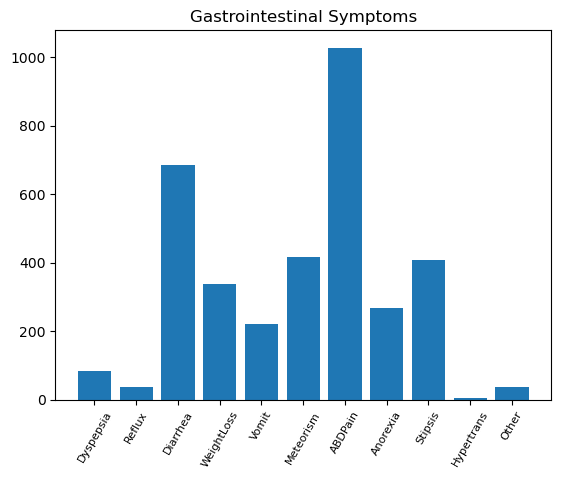

In [ ]:
# BARCHART

Total_GI_Symptoms = Dataset['GI_Symptoms'].sum()
Dyspepsia = Dataset['GI_Dyspepsia'].sum()
Reflux = Dataset['GI_Reflux'].sum()
Diarrhea = Dataset['GI_Diarrhea'].sum()
WeightLoss = Dataset['GI_WeightLoss'].sum()
Vomit = Dataset['GI_Vomit'].sum()
Meteorism = Dataset['GI_Meteorism'].sum()
ABDPain = Dataset['GI_AbdominalPain'].sum()
Anorexia = Dataset['GI_Anorexia'].sum()
Stipsis = Dataset['GI_Stipsis'].sum()
Hypertransaminasemia = Dataset['GI_Hypertransaminasemia'].sum()
Other = Dataset['GI_Other'].sum()

plt.figure(4)
plt.bar(['Dyspepsia', 'Reflux', 'Diarrhea', 'WeightLoss', 'Vomit', 'Meteorism', 'ABDPain', 'Anorexia', 'Stipsis', 'Hypertrans', 'Other'],
        [Dyspepsia, Reflux, Diarrhea, WeightLoss, Vomit, Meteorism, ABDPain, Anorexia, Stipsis, Hypertransaminasemia, Other], width=0.8)
plt.xticks(['Dyspepsia', 'Reflux', 'Diarrhea', 'WeightLoss', 'Vomit', 'Meteorism', 'ABDPain', 'Anorexia', 'Stipsis', 'Hypertrans', 'Other'], fontsize=8, rotation=60)
plt.title("Gastrointestinal Symptoms")
plt.show()


Since there are only a few observations in some columns, we can think of joining them:
- Dyspepsia, Reflux, Vomit --> Upper GI (upper gastrointestinal symptoms)
- Hypertrans --> joins Other

In [ ]:
Dataset['GI_Upper'] = 0

Dataset['GI_Upper'][Dataset['GI_Dyspepsia']==1] = 1
Dataset['GI_Upper'][Dataset['GI_Reflux']==1] = 1
Dataset['GI_Upper'][Dataset['GI_Vomit']==1] = 1

Dataset['GI_Other'][Dataset['GI_Hypertransaminasemia']==1] = 1


# Drop columns

Dataset = Dataset.drop(columns=['GI_Dyspepsia','GI_Reflux','GI_Vomit','GI_Hypertransaminasemia'])
Dataset = Dataset.drop(columns='GI_None')


C:\Users\paolo\AppData\Local\Temp\ipykernel_6976\2984211010.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Dataset['GI_Upper'][Dataset['GI_Dyspepsia']==1] = 1
C:\Users\paolo\AppData\Local\Temp\ipykernel_6976\2984211010.py:3: SettingWith

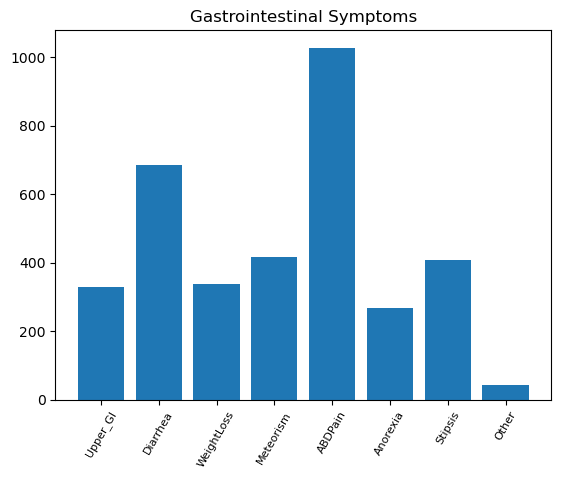

In [ ]:
# New distribution

Total_GI_Symptoms = Dataset['GI_Symptoms'].sum()
Upper_GI = Dataset['GI_Upper'].sum()
Diarrhea = Dataset['GI_Diarrhea'].sum()
WeightLoss = Dataset['GI_WeightLoss'].sum()
Meteorism = Dataset['GI_Meteorism'].sum()
ABDPain = Dataset['GI_AbdominalPain'].sum()
Anorexia = Dataset['GI_Anorexia'].sum()
Stipsis = Dataset['GI_Stipsis'].sum()
Other = Dataset['GI_Other'].sum()

plt.figure(5)
plt.bar(['Upper_GI', 'Diarrhea', 'WeightLoss', 'Meteorism', 'ABDPain', 'Anorexia', 'Stipsis', 'Other'],
        [Upper_GI, Diarrhea, WeightLoss, Meteorism, ABDPain, Anorexia, Stipsis, Other], width=0.8)
plt.xticks(['Upper_GI', 'Diarrhea', 'WeightLoss', 'Meteorism', 'ABDPain', 'Anorexia', 'Stipsis', 'Other'], fontsize=8, rotation=60)
plt.title("Gastrointestinal Symptoms")
plt.show()

## Neurological Symptoms

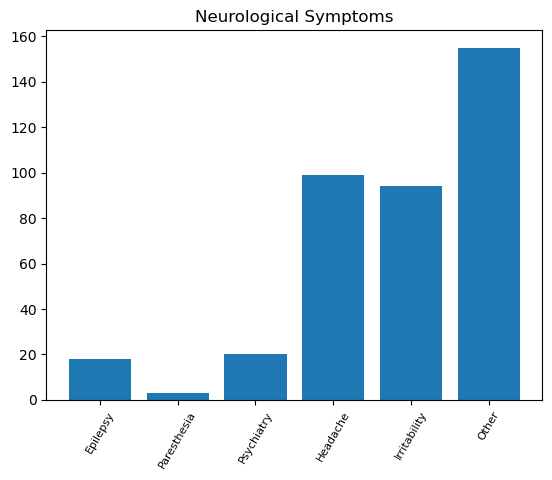

In [ ]:
# BARCHART

Total_Neuro = Dataset['Neurological_Sympt'].sum()
Epilepsy = Dataset['Neuro_Epilepsy'].sum()
Paresthesia = Dataset['Neuro_Paresthesia'].sum()
Psychiatry = Dataset['Neuro_Psychiatry'].sum()
Headache = Dataset['Neuro_Headache'].sum()
Irritability = Dataset['Neuro_Irritability'].sum()
Other = Dataset['Neuro_Other'].sum()


plt.figure(6)
plt.bar(['Epilepsy', 'Paresthesia', 'Psychiatry', 'Headache', 'Irritability', 'Other'],
        [Epilepsy, Paresthesia, Psychiatry, Headache, Irritability, Other], width=0.8)
plt.xticks(['Epilepsy', 'Paresthesia', 'Psychiatry', 'Headache', 'Irritability', 'Other'], fontsize=8, rotation=60)
plt.title("Neurological Symptoms")
plt.show()


As done above, since there are only a few observations in some columns, we can think of joining them:
- Epilepsy, Paresthesia --> joins Other

In [ ]:
Dataset['Neuro_Other'][Dataset['Neuro_Epilepsy']==1] = 1
Dataset['Neuro_Other'][Dataset['Neuro_Paresthesia']==1] = 1

# Drop columns

Dataset = Dataset.drop(columns=['Neuro_Epilepsy','Neuro_Paresthesia'])
Dataset = Dataset.drop(columns='Neuro_Not_Reported')

C:\Users\paolo\AppData\Local\Temp\ipykernel_6976\897503203.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Dataset['Neuro_Other'][Dataset['Neuro_Epilepsy']==1] = 1
C:\Users\paolo\AppData\Local\Temp\ipykernel_6976\897503203.py:1: SettingW

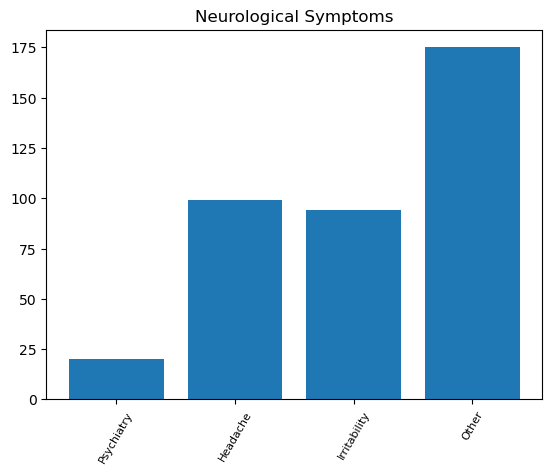

In [ ]:
# New distribution

Total_Neuro = Dataset['Neurological_Sympt'].sum()
Psychiatry = Dataset['Neuro_Psychiatry'].sum()
Headache = Dataset['Neuro_Headache'].sum()
Irritability = Dataset['Neuro_Irritability'].sum()
Other = Dataset['Neuro_Other'].sum()


plt.figure(6)
plt.bar(['Psychiatry', 'Headache', 'Irritability', 'Other'],
        [Psychiatry, Headache, Irritability, Other], width=0.8)
plt.xticks(['Psychiatry', 'Headache', 'Irritability', 'Other'], fontsize=8, rotation=60)
plt.title("Neurological Symptoms")
plt.show()

## Autoimmune Diseases

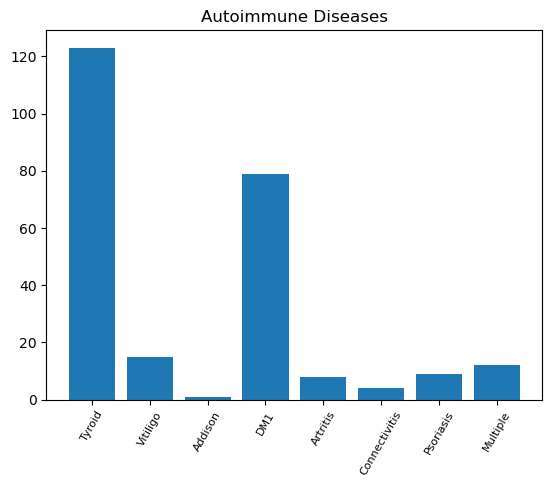

In [ ]:
# BARCHART

Total_Autoimmune = Dataset['Autoimmune_Dis'].sum()
Tyroid = Dataset['Autoimmune_Tyroid_Dis'].sum()
Vitiligo = Dataset['Autoimmune_Vitiligo'].sum()
Addison = Dataset['Autoimmune_Addison'].sum()
DM1 = Dataset['Autoimmune_Type1_Diabetes'].sum()
Artritis = Dataset['Autoimmune_Artritis'].sum()
Connectivitis = Dataset['Autoimmune_Connectivitis'].sum()
Psoriasis = Dataset['Autoimmune_Psoriasis'].sum()
Multiple = Dataset['Autoimmune_Multiple'].sum()


plt.figure(7)
plt.bar(['Tyroid', 'Vitiligo', 'Addison', 'DM1', 'Artritis', 'Connectivitis', 'Psoriasis', 'Multiple'],
        [Tyroid, Vitiligo, Addison, DM1, Artritis, Connectivitis, Psoriasis, Multiple], width=0.8)
plt.xticks(['Tyroid', 'Vitiligo', 'Addison', 'DM1', 'Artritis', 'Connectivitis', 'Psoriasis', 'Multiple'], fontsize=8, rotation=60)
plt.title("Autoimmune Diseases")
plt.show()

As done above, since there are only a few observations in some columns, we can think of joining them:
- Vitiligo, Artritis, Connectivitis, Psoriasis --> Skin/Tissues
- Addison, Multiple --> Others

In [ ]:
Dataset['Autoimmune_Skin/Tissues'] = 0
Dataset['Autoimmune_Others'] = 0

Dataset['Autoimmune_Skin/Tissues'][Dataset['Autoimmune_Vitiligo']==1] = 1
Dataset['Autoimmune_Skin/Tissues'][Dataset['Autoimmune_Artritis']==1] = 1
Dataset['Autoimmune_Skin/Tissues'][Dataset['Autoimmune_Connectivitis']==1] = 1
Dataset['Autoimmune_Skin/Tissues'][Dataset['Autoimmune_Psoriasis']==1] = 1

Dataset['Autoimmune_Others'][Dataset['Autoimmune_Addison']==1] = 1
Dataset['Autoimmune_Others'][Dataset['Autoimmune_Multiple']==1] = 1


# Drop columns

Dataset = Dataset.drop(columns=['Autoimmune_Vitiligo','Autoimmune_Artritis','Autoimmune_Connectivitis','Autoimmune_Psoriasis','Autoimmune_Addison','Autoimmune_Multiple'])


C:\Users\paolo\AppData\Local\Temp\ipykernel_6976\1071932201.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Dataset['Autoimmune_Skin/Tissues'][Dataset['Autoimmune_Vitiligo']==1] = 1
C:\Users\paolo\AppData\Local\Temp\ipykernel_6976\107193

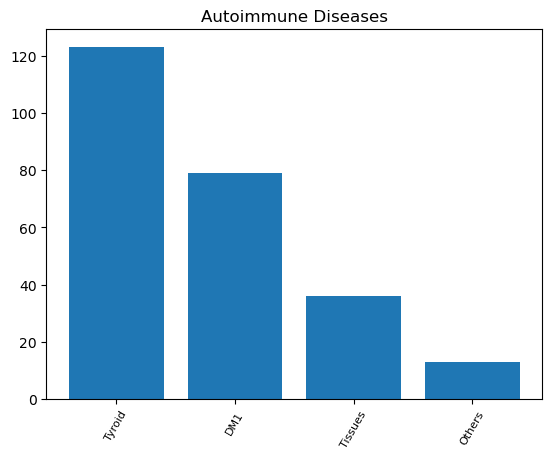

In [ ]:
# New Distribution

Total_Autoimmune = Dataset['Autoimmune_Dis'].sum()
Tyroid = Dataset['Autoimmune_Tyroid_Dis'].sum()
DM1 = Dataset['Autoimmune_Type1_Diabetes'].sum()
Skin = Dataset['Autoimmune_Skin/Tissues'].sum()
Others = Dataset['Autoimmune_Others'].sum()


plt.figure(8)
plt.bar(['Tyroid', 'DM1', 'Tissues','Others'],
        [Tyroid, DM1, Skin, Others], width=0.8)
plt.xticks(['Tyroid', 'DM1', 'Tissues','Others'], fontsize=8, rotation=60)
plt.title("Autoimmune Diseases")
plt.show()

## Drop useless columns

In [ ]:
Dataset = Dataset.drop(columns=['Education_Parents', 'Socioecon_Status', 'Exemption','Growth_Delay'])

Now that we have fixed the columns related to symptoms and complications, we can reorder them and then export the new Dataset

In [ ]:
Dataset.columns

Index(['Patient_ID', 'Local_ID', 'Center', 'Sex', 'Ethnicity',
       'Year_of_Diagnosis', 'Age_at_Diagnosis', 'Age_Years', 'Age_Months',
       'Month_Gluten_Started', 'Weight', 'Height', 'Growth Delay Updated',
       'BMI', 'Recent_Gastroenteritis', 'Num_Siblings', 'Blood_Count',
       'BloodCount_Microcytic_Anemia', 'GI_Symptoms', 'GI_Diarrhea',
       'GI_WeightLoss', 'GI_Meteorism', 'GI_AbdominalPain', 'GI_Anorexia',
       'GI_Stipsis', 'GI_Other', 'Neurological_Sympt', 'Neuro_Psychiatry',
       'Neuro_Other', 'Neuro_Headache', 'Neuro_Irritability',
       'Delayed_Menarche', 'Teeth_Anomalies', 'Blood_Proteins_Anomalies',
       'Asthenia', 'Osteopenia', 'Autoimmune_Dis', 'Autoimmune_Tyroid_Dis',
       'Autoimmune_Type1_Diabetes', 'Common_deficit_Ig',
       'Selective_deficit_IgA', 'Down_Syndrome', 'Dermatisis_Herpetiformis',
       'Familirity', 'Months_from_symptoms', 'Reason_Diagnosis',
       'First_Diagnosis_Doctor', 'Diagnosis_modality',
       'Doctor-dependent_Delay'

In [ ]:
# REORDERING COLUMNS

Dataset = Dataset[['Patient_ID', 'Local_ID', 'Center', 'Sex', 'Ethnicity',
       'Year_of_Diagnosis', 'Age_at_Diagnosis', 'Age_Years', 'Age_Months',
       'Month_Gluten_Started', 'Weight', 'Height', 'Growth Delay Updated',
       'BMI', 'Recent_Gastroenteritis', 'Num_Siblings',
       'Blood_Count', 'BloodCount_Microcytic_Anemia', 'GI_Symptoms', 'GI_Upper', 'GI_Diarrhea',
       'GI_WeightLoss', 'GI_Meteorism', 'GI_AbdominalPain', 'GI_Anorexia',
       'GI_Stipsis', 'GI_Other', 'Neurological_Sympt', 'Neuro_Psychiatry',
       'Neuro_Other', 'Neuro_Headache', 'Neuro_Irritability',
       'Delayed_Menarche', 'Teeth_Anomalies', 'Blood_Proteins_Anomalies',
       'Asthenia', 'Osteopenia', 'Autoimmune_Dis',
       'Autoimmune_Tyroid_Dis', 'Autoimmune_Type1_Diabetes', 'Autoimmune_Skin/Tissues', 'Autoimmune_Others',
       'Common_deficit_Ig', 'Selective_deficit_IgA', 'Down_Syndrome',
       'Dermatisis_Herpetiformis', 'Familirity', 'Months_from_symptoms',
       'Reason_Diagnosis', 'First_Diagnosis_Doctor', 'Diagnosis_modality',
       'Doctor-dependent_Delay', 'Total_Diagnostic_Delay', 'Wrong_Diagnosis',
       'Wrong_Diagnosis_2', 'Therapy_before_Diagn', 'CLASSIFICATION',
       'Complications', 'Complications_Hospitalization',
       'Complications_DayHospital', 'Complications_Iron_infusion',
       'Complications_Albumin', 'HLA Haplotype', 'Anti-tTG', 'IgA_Absolute',
       'EMA', 'IgG_Absolute', 'IgG_10X', 'IgG_10X_Categoriale',
       'Endoscopy_Duodenum', 'MARSH_Histology', 'Corazza_Histology',
       'Biagi_Diet_Adherence', 'VAS_Score_Adherence']]

# RENAME COLUMNS

col_names = {'Familirity':'Familiarity'}
Dataset = Dataset.rename(columns=col_names)


In [ ]:
# SAVE DATASET

Dataset.to_excel("Data_explorative_analysis_part1.xlsx", index=False)